# CRISPR knockouts

A CRISPR screen asks what a gene does by removing it. Genes whose products work together, such as the subunits
of one protein complex, should give the same phenotype when knocked out. A good morphological map therefore
recovers known complexes, and it places a gene of unknown function next to its partners.

This page uses the CRISPR arm of JUMP {cite:p}`Chandrasekaran_2023`: U2OS cells, each well targeting one gene.
{func}`~mantispy.ds.jump_crispr` returns the profiles as the consortium assembled them, corrected for well
position and cell count, normalized and feature-selected. It joins the gene each well targets, which wells are
controls, and the chromosome arm each gene sits on.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import mantispy as mt

wells = mt.ds.jump_crispr()
obs = wells.obs
is_trt = obs["Metadata_Control_Type"] == "trt"
treated = obs[is_trt]
{
    "wells": wells.n_obs,
    "features": wells.n_vars,
    "plates": obs["Metadata_Plate"].nunique(),
    "genes": treated["Metadata_Perturbation"].nunique(),
    "median wells per gene": int(treated.groupby("Metadata_Perturbation", observed=True).size().median()),
    "control wells": obs.loc[~is_trt, "Metadata_Perturbation"].astype(str).value_counts().to_dict(),
}

{'wells': 51185,
 'features': 595,
 'plates': 148,
 'genes': 7974,
 'median wells per gene': 5,
 'control wells': {'no-guide': 4724, 'non-targeting': 2754, 'PLK1': 569}}

About 8,000 genes, five wells each, over 148 plates. The negative controls are wells with no guide and wells
whose guide targets nothing in the genome. The positive control is PLK1, a kinase cells need to divide.

The consortium's CRISPR recipe continues from these profiles by sphering against the negative controls. Unlike
BBBC021 on [Plate artifacts and corrections](../profiles/artifacts.ipynb), there are far more control wells than
features here, 7,478 against 595, so the control covariance is well determined. A copy is kept as published,
for a comparison further down. `modz` weights each well by how well it agrees with the gene's other wells, which
suits five noisy replicates.

In [2]:
def per_gene(profiles):
    """One modz signature per targeted gene, leaving out the controls."""
    signatures = mt.tl.consensus(profiles, method="modz")
    return signatures[signatures.obs["Metadata_Control_Type"].astype(str) == "trt"].copy()


published = per_gene(wells)
mt.pp.sphere(wells, reference="negcon")

## Which knockouts have a phenotype?

Two questions, both answered with mAP. Does a gene's knockout stand apart from the negative controls on its own
plates (`mode="activity"`)? And do its wells find each other among all the other knockouts
(`mode="replicability"`)?

With nearly 8,000 genes the permutation null has to be large. `tl.map` cannot return a p-value below one over
the number of draws plus one, and a correction over nearly 8,000 groups at 5% needs about 160,000 draws before a
single gene can be called on its own.

In [3]:
genes_screened = set(treated["Metadata_Perturbation"].astype(str))
rows = {}
for mode in ("activity", "replicability"):
    mt.tl.map(wells, mode=mode, null_size=200_000, key_added=mode)
    table = wells.uns["mantispy"][mode]
    table = table[table["Metadata_Perturbation"].astype(str).isin(genes_screened)]
    rows[mode] = {
        "genes scored": len(table),
        "called at q < 0.05": int(table["below_corrected_p"].sum()),
        "mean mAP": round(float(table["mean_average_precision"].mean()), 3),
    }
pd.DataFrame(rows).T

,genes scored,called at q < 0.05,mean mAP
activity,7971.0,4715.0,0.553
replicability,7971.0,1175.0,0.107


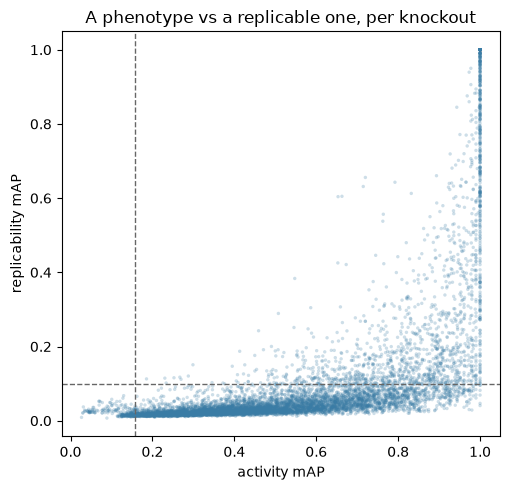

In [4]:
activity_tab = wells.uns["mantispy"]["activity"].set_index("Metadata_Perturbation")
repl_tab = wells.uns["mantispy"]["replicability"].set_index("Metadata_Perturbation")
screened = sorted(genes_screened & set(activity_tab.index) & set(repl_tab.index))
phenotype = (
    pd.DataFrame(
        {
            "activity": activity_tab["mean_average_precision"],
            "replicability": repl_tab["mean_average_precision"],
            "activity_called": activity_tab["below_corrected_p"],
            "replicability_called": repl_tab["below_corrected_p"],
        }
    )
    .loc[screened]
    .dropna()
)
# The mAP a gene needs to clear q < 0.05, read off the genes called on each axis.
activity_cut = phenotype.loc[phenotype["activity_called"], "activity"].min()
repl_cut = phenotype.loc[phenotype["replicability_called"], "replicability"].min()

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(phenotype["activity"], phenotype["replicability"], s=6, alpha=0.25, color="#3a7ca5", edgecolor="none")
ax.axvline(activity_cut, ls="--", lw=1, color="0.4")
ax.axhline(repl_cut, ls="--", lw=1, color="0.4")
ax.set(xlabel="activity mAP", ylabel="replicability mAP", title="A phenotype vs a replicable one, per knockout")
fig.tight_layout()
plt.show()

4,715 of 7,971 knockouts stand apart from the controls, but only 1,175 are told apart from the other knockouts
by their own wells. Many genes have a phenotype, and fewer have one that sets them apart from other knockouts.

In [5]:
genes = per_gene(wells)
genes.shape

(7971, 595)

## Do subunits of one complex look alike?

{func}`~mantispy.ds.corum` returns the human protein complexes of CORUM, as the benchmark of
{cite:t}`Celik_2024` distributes them. Two genes of one complex count as a related pair, and
{func}`~mantispy.metrics.known_relationships` asks how many related pairs land in either tail of the map's
similarity distribution. `n_permutations` measures chance on this map by shuffling which gene each annotation
row names.

In [6]:
complexes = mt.ds.corum()
rows = []
for percentile in (1.0, 5.0, 10.0):
    result = mt.metrics.known_relationships(genes, complexes, percentile=percentile, n_permutations=100).iloc[0]
    rows.append(
        {
            "tail width (%)": percentile,
            "shuffled annotation": float(result["null"]),
            "observed": float(result["value"]),
            "p": float(result["p_value"]),
        }
    )
pd.DataFrame(rows).round(3)

,tail width (%),shuffled annotation,observed,p
0,1.0,0.038,0.133,0.01
1,5.0,0.143,0.259,0.01
2,10.0,0.253,0.371,0.01


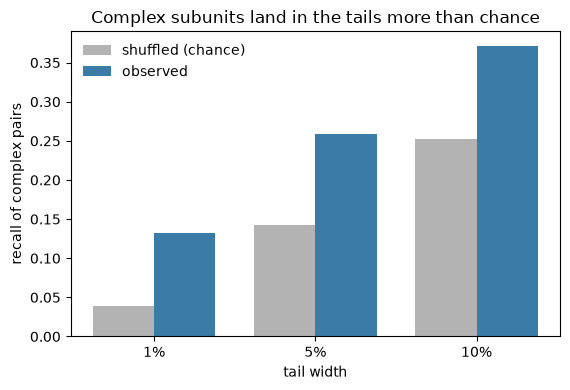

In [7]:
recall = pd.DataFrame(rows)
x = np.arange(len(recall))
width = 0.38
fig, ax = plt.subplots(figsize=(5.8, 4))
ax.bar(x - width / 2, recall["shuffled annotation"], width, label="shuffled (chance)", color="0.7")
ax.bar(x + width / 2, recall["observed"], width, label="observed", color="#3a7ca5")
ax.set_xticks(x, [f"{p:g}%" for p in recall["tail width (%)"]])
ax.set(
    xlabel="tail width", ylabel="recall of complex pairs", title="Complex subunits land in the tails more than chance"
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

At every tail width, pairs from one complex land in the tails more often than chance on this map, 13% against
4% at the strictest, and no shuffle reaches the observed recall. The chance level is measured rather than
assumed: at 1% the tails would hold 2% of random pairs, but the shuffled annotation sits at 4%, as it does when
some genes belong to many complexes and most to few.

{func}`~mantispy.tl.pathway_coherence` asks the same per complex: are the profiles of its genes more alike than
random sets of the same size?

In [8]:
mt.tl.pathway_coherence(genes, complexes)
coherence = genes.uns["mantispy"]["pathway_coherence"]
print(f"{int((coherence['qvalue'] < 0.05).sum())} of {len(coherence)} complexes coherent at q < 0.05")
coherence.head(8).round(3)

135 of 269 complexes coherent at q < 0.05


,set,n_genes,coherence,pvalue,qvalue
0,CCT complex (chaperonin containing TCP1 complex),8,0.762,0.001,0.003
1,BBS-chaperonin complex,6,0.737,0.001,0.003
2,PA700 complex,6,0.624,0.001,0.003
3,PA28gamma-20S proteasome,13,0.563,0.001,0.003
4,20S proteasome,13,0.563,0.001,0.003
5,PA28-20S proteasome,13,0.563,0.001,0.003
6,EIF2B1-EIF2B2-EIF2B3-EIF2B4-EIF2B5 complex,5,0.542,0.001,0.003
7,PA700-20S-PA28 complex,19,0.515,0.001,0.003


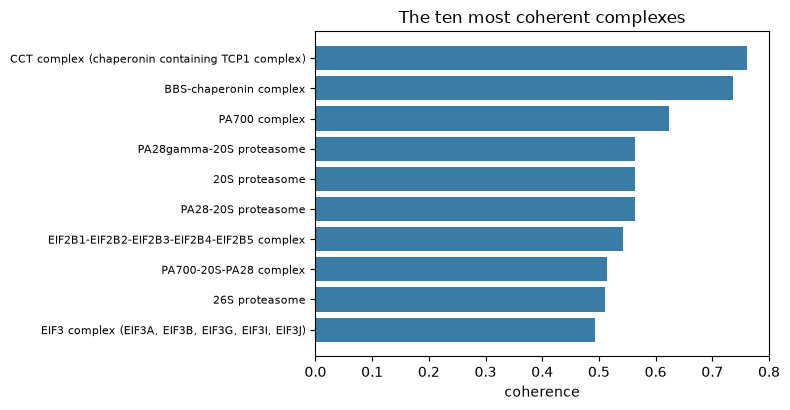

In [9]:
top = coherence.nlargest(10, "coherence").iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(range(len(top)), top["coherence"], color="#3a7ca5")
ax.set_yticks(range(len(top)), top["set"], fontsize=8)
ax.set(xlabel="coherence", title="The ten most coherent complexes")
fig.tight_layout()
plt.show()

Half of the complexes with at least five screened genes are coherent. The top of the list is machinery a
dividing cell cannot do without: the chaperonin that folds actin and tubulin, the proteasome in several of its
CORUM entries, and the translation initiation factor eIF2B. The BBS-chaperonin entry is coherent through the
chaperonin subunits it shares.

## Nearest neighbours

A gene of unknown function is annotated by the knockouts nearest to it. Four well-known genes show what that
looks like here. `*` marks a partner from one of the query's CORUM complexes, and `^` a gene on its chromosome
arm.

In [10]:
def unit_rows(profiles):
    """The profiles scaled to unit length, so a matrix product gives cosine similarities."""
    values = np.asarray(profiles.X, dtype=np.float64)
    return values / np.linalg.norm(values, axis=1, keepdims=True)


unit = unit_rows(genes)
symbols = genes.obs["Metadata_Perturbation"].astype(str).to_numpy()
arms = genes.obs["Metadata_ChromosomeArm"].astype(object).to_numpy()


def neighbours(query, k=8):
    """The k knockouts most like the query's; * shares a CORUM complex with it, ^ sits on its chromosome arm."""
    i = int(np.flatnonzero(symbols == query)[0])
    shared = complexes["source"].isin(complexes.loc[complexes["target"] == query, "source"])
    partners = set(complexes.loc[shared, "target"])
    nearest = [j for j in np.argsort(-(unit @ unit[i])) if j != i][:k]
    marks = [
        symbols[j] + ("*" if symbols[j] in partners else "") + ("^" if pd.notna(arms[i]) and arms[j] == arms[i] else "")
        for j in nearest
    ]
    return ", ".join(marks)


for query in ("PSMB2", "CCT2", "EIF3B", "POLR2A"):
    print(f"{query:7s}{neighbours(query)}")

PSMB2  PSMB3*, PSMB7*, PSMB4*, PSMB6*, PSMA4*, PSMA6*, PSMA1*, PSMA5*^
CCT2   TCP1*, CCT6A*, CCT4*, CCT3*, CCT5*, CCT7*, CCT8*, ILF2
EIF3B  EIF3I*, EIF1AX, EIF3A*, EIF2S3, EIF3G*, EIF3E*, DDX3X, EIF2S1
POLR2A EIF4A3, HSPA5, NXF1, MAT2A, POLR2G*, RAN, ACOT6, WEE1


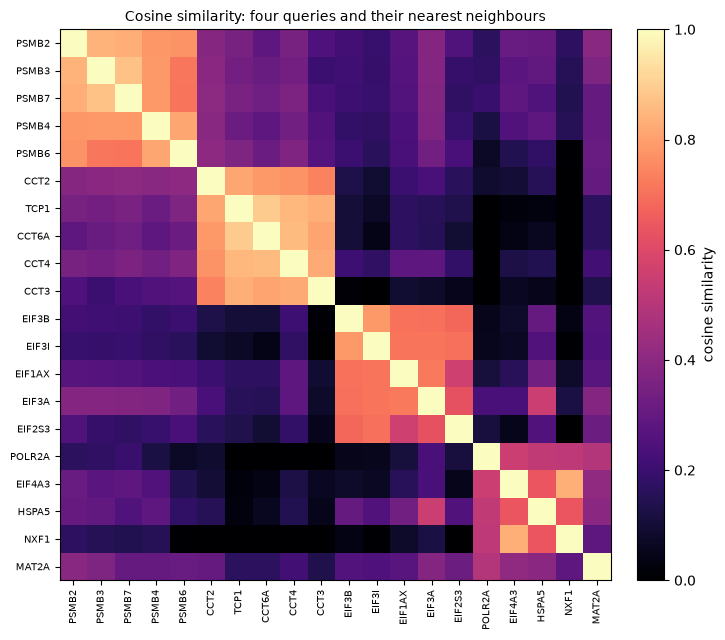

In [11]:
seeds = ["PSMB2", "CCT2", "EIF3B", "POLR2A"]
picked = []
for query in seeds:
    i = int(np.flatnonzero(symbols == query)[0])
    nearest = [j for j in np.argsort(-(unit @ unit[i])) if j != i][:4]
    for j in [i, *nearest]:
        if j not in picked:
            picked.append(j)
picked = np.array(picked)
labels = symbols[picked]
block = unit[picked] @ unit[picked].T

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(block, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels)), labels, fontsize=7)
ax.set_title("Cosine similarity: four queries and their nearest neighbours", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cosine similarity")
fig.tight_layout()
plt.show()

Three of the four read as their complexes. PSMB2's eight nearest knockouts are all proteasome subunits. CCT2's
are seven chaperonin subunits and ILF2. EIF3B's are translation initiation factors: four eIF3 subunits, eIF2,
eIF1A and the helicase DDX3X. POLR2A, the largest subunit of RNA polymerase II, finds only one polymerase subunit
among its neighbours. Several of the others, such as HSPA5 and WEE1, are genes whose knockouts leave few cells
behind, as its own does; the last section measures that.

Only one of these neighbours sits on its query's chromosome arm.

## Neighbours on the same chromosome arm

A Cas9 cut can do more than break one gene: it can truncate the chromosome arm around it. Knockouts of genes on
one arm then share a phenotype that says nothing about the genes. jump-profiling-recipe corrects for this with
the same loci that fill `Metadata_ChromosomeArm`.

In [12]:
def same_arm(profiles, k=10):
    """Share of each gene's k nearest knockouts that sit on its chromosome arm."""
    arm = profiles.obs["Metadata_ChromosomeArm"].astype(object).to_numpy()
    known = pd.notna(arm)
    arm, values = arm[known], unit_rows(profiles)[known]
    similarity = values @ values.T
    np.fill_diagonal(similarity, -np.inf)
    nearest = np.argpartition(-similarity, k, axis=1)[:, :k]
    return float((arm[nearest] == arm[:, None]).mean())


sizes = pd.Series(arms).value_counts()
n = sizes.sum()
same_arm_fractions = {
    "a random pair (chance)": float((sizes * (sizes - 1)).sum() / (n * (n - 1))),
    "10 nearest, as published": same_arm(published),
    "10 nearest, after sphering": same_arm(genes),
}

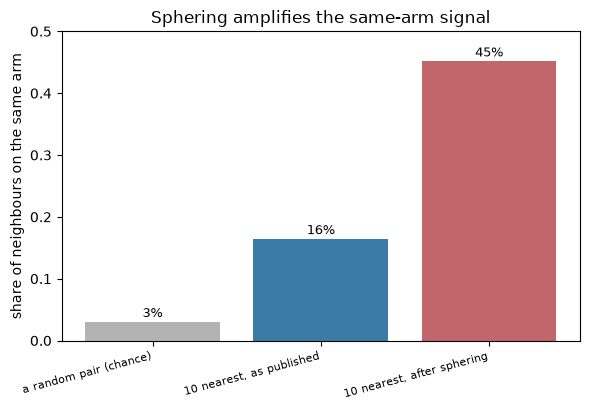

In [13]:
labels = list(same_arm_fractions)
values = [same_arm_fractions[k] for k in labels]

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(range(len(labels)), values, color=["0.7", "#3a7ca5", "#c1666b"])
for i, v in enumerate(values):
    ax.text(i, v + 0.008, f"{v:.0%}", ha="center", fontsize=9)
ax.set_xticks(range(len(labels)), labels, rotation=15, ha="right", fontsize=8)
ax.set(ylabel="share of neighbours on the same arm", ylim=(0, 0.5), title="Sphering amplifies the same-arm signal")
fig.tight_layout()
plt.show()

Two genes drawn at random share an arm 3% of the time. A gene's ten nearest knockouts share it 16% of the time
as published, more than five times chance, and 45% after sphering. Sphering scales up the directions the
controls barely vary in, and the arm signal is one of them, because no control well has a cut.

That does not undo the complexes above, whose partners were rarely on the same arm. It does make a neighbour on
the query's own arm weak evidence of a shared function, and it is the reason to correct for the arm before
reading guilt by association across the genome.

## Essential genes lose cells

A knockout of a gene the cell needs leaves fewer cells. `viability` below is each well's cell count against the
median of the negative controls on its plate, as a median per gene.

In [14]:
plate_controls = obs[obs["Metadata_Control"]].groupby("Metadata_Plate", observed=True)["Metadata_CellCount"].median()
viability = obs["Metadata_CellCount"] / obs["Metadata_Plate"].map(plate_controls).astype(float)
by_gene = viability[is_trt].groupby(treated["Metadata_Perturbation"], observed=True).median()
activity = wells.uns["mantispy"]["activity"].set_index("Metadata_Perturbation")["mean_average_precision"]
cells = pd.DataFrame({"viability": by_gene}).join(activity.rename("activity mAP")).dropna()

proteasome = complexes.loc[complexes["source"] == "26S proteasome", "target"]
print(
    {
        "median viability, every gene": round(float(cells["viability"].median()), 2),
        "median viability, 26S proteasome": round(float(cells["viability"].reindex(proteasome).median()), 2),
        "Spearman, viability against activity mAP": round(
            float(spearmanr(cells["viability"], cells["activity mAP"]).statistic), 2
        ),
    }
)
cells.nsmallest(8, "viability").round(2)

{'median viability, every gene': 0.75, 'median viability, 26S proteasome': 0.32, 'Spearman, viability against activity mAP': -0.54}


,viability,activity mAP
Metadata_Perturbation,,
POLR2A,0.19,0.85
KIF11,0.22,1.00
RRM2,0.23,0.93
WEE1,0.23,1.00
MDM2,0.24,1.00
HSPA5,0.24,1.00
CASP8AP2,0.25,1.00
RRM1,0.25,1.00


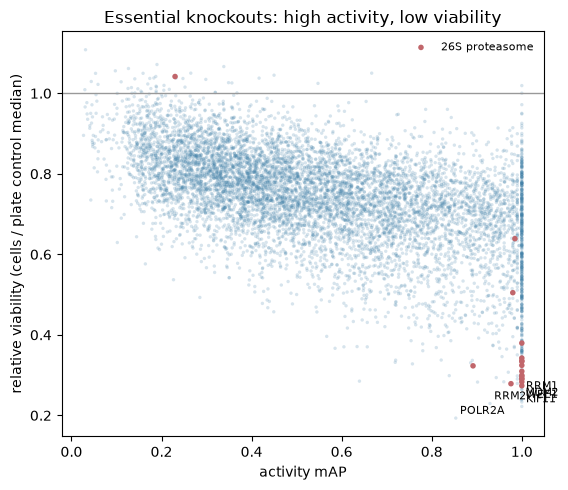

In [15]:
in_proteasome = cells.index.isin(set(proteasome))

fig, ax = plt.subplots(figsize=(5.8, 5))
ax.scatter(cells["activity mAP"], cells["viability"], s=6, alpha=0.2, color="#3a7ca5", edgecolor="none")
ax.scatter(
    cells.loc[in_proteasome, "activity mAP"],
    cells.loc[in_proteasome, "viability"],
    s=16,
    color="#c1666b",
    edgecolor="none",
    label="26S proteasome",
)
for gene in ["POLR2A", "RRM1", "RRM2", "WEE1", "KIF11", "MDM2"]:
    if gene in cells.index:
        ax.annotate(
            gene,
            (cells.loc[gene, "activity mAP"], cells.loc[gene, "viability"]),
            fontsize=8,
            xytext=(3, 3),
            textcoords="offset points",
        )
ax.axhline(1.0, color="0.6", lw=1)
ax.set(
    xlabel="activity mAP",
    ylabel="relative viability (cells / plate control median)",
    title="Essential knockouts: high activity, low viability",
)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Proteasome knockouts keep a third of the controls' cells, against three quarters for the median gene. The
knockouts that lose the most are genes a dividing cell needs: RNA polymerase II, ribonucleotide reductase (RRM1
and RRM2), the checkpoint kinase WEE1, and KIF11, the kinesin Eg5 that BBBC021's Eg5 inhibitors target. MDM2 is
among them too: without it p53 is no longer held in check, and U2OS cells carry a working p53.

Phenotype strength tracks cell loss even though the profiles were corrected for cell count: the less viable a
knockout, the higher its activity mAP, at a rank correlation of −0.54. A strong phenotype can be a dying cell,
as [Hits, effects and cell loss](../compounds/hits.ipynb) shows for compounds. Read
the neighbours of a lethal knockout as neighbours in dying, as POLR2A's were.

## Summary

- {func}`~mantispy.ds.jump_crispr` names every well's gene, its control type and its chromosome arm, and
  {func}`~mantispy.ds.corum` supplies complexes to check the map against.
- Many knockouts have a phenotype; a replicable, specific one is rarer. Report both.
- Measure chance for complex recovery with `n_permutations`. Here the shuffled annotation sits above twice the
  tail width.
- Genes of one complex phenocopy each other, which is what guilt by association rests on.
- Knockouts of neighbouring genes also look alike, because of the cut rather than the genes, and sphering
  amplifies it. Check a neighbour's chromosome arm before reading it as a shared function.
- The most lethal knockouts have some of the strongest phenotypes, and cell loss tracks phenotype strength. Read
  cell loss beside the map.